<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Descargar el archivo worldbank_dataset.csv (commiteado en el repo, sin depender de Google Drive)
!wget -q -O worldbank_dataset.csv https://raw.githubusercontent.com/AlesioRios/Laboratorio-de-Datos-II/main/data/worldbank_dataset.csv

In [2]:
import pandas as pd

df = pd.read_csv('/content/worldbank_dataset.csv')

# Ejercicio 1.1 — Análisis exploratorio inicial

EDA de diagnóstico antes de cualquier tratamiento de faltantes, transformación o estandarización (eso es Ejercicio 1, puntos 2 a 4, y queda para después). El objetivo acá es entender qué hay: nulos, rango/orden de magnitud de cada variable, y forma de las distribuciones.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from IPython.display import display, HTML


def estilizar(df, cmap='Blues', precision=2):
  # Codifica una tabla con color en vez de imprimirla como texto plano (heatmap-style, por columna).
  # Ademas de background_gradient, se agregan estilos de tabla explicitos: al extraer el
  # HTML con .to_html() para mostrarlo dentro de un <div> propio (mostrar_lado_a_lado),
  # se pierde el CSS por default que Colab/Jupyter le pone a un DataFrame (padding, bordes,
  # tipografia) - sin esto se ve mas apretado/plano que una tabla mostrada normalmente.
  estilos_tabla = [
      {'selector': 'th', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de'), ('background-color', '#f6f8fa')]},
      {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'center'), ('border', '1px solid #d0d7de')]},
      {'selector': ''  , 'props': [('border-collapse', 'collapse'), ('font-size', '13px')]},
  ]
  return (
      df.style
      .background_gradient(cmap=cmap, axis=0)
      .format(precision=precision)
      .set_table_styles(estilos_tabla)
  )


def mostrar_lado_a_lado(tablas, cmap='Blues', precision=2):
  # Muestra varias tablas en una fila horizontal (en vez de apiladas) para que entren juntas en pantalla.
  # Cada tabla queda dentro de una tarjeta con borde propio, con mas separacion entre ellas
  # y entre el titulo y la tabla, para que se vea prolijo en vez de amontonado.
  bloques = []
  for titulo, df in tablas:
    bloques.append(
        "<div style='margin:0 32px 20px 0; padding:12px 14px; "
        "border:1px solid #d0d7de; border-radius:10px;'>"
        f"<div style='font-weight:600; margin-bottom:8px;'>{titulo}</div>"
        f"{estilizar(df, cmap=cmap, precision=precision).to_html()}</div>"
    )
  display(HTML("<div style='display:flex; flex-wrap:wrap;'>" + ''.join(bloques) + "</div>"))


# Variable objetivo de todo el TP3 (problema de regresion)
TARGET = 'gdp_per_capita_current_us$'

# country/iso_code/countryiso3 son tres codificaciones del mismo pais (misma cardinalidad,
# 144 cada una) - se excluyen del analisis numerico para no analizar tres veces lo mismo.
COLUMNAS_ID = ['country', 'iso_code', 'countryiso3']
columnas_numericas = [c for c in df.columns if c not in COLUMNAS_ID and c != 'year']

### 1. Estructura del dataset

¿Con cuántos datos contamos y de qué tipo es cada columna?

In [4]:
print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Paises: {df['country'].nunique()} | Anios: {df['year'].min()}-{df['year'].max()} (panel pais-anio)")

display(df.dtypes.value_counts().rename('Cantidad de columnas').to_frame())
df.head()

Dataset: 3429 filas x 64 columnas
Paises: 144 | Anios: 1995-2022 (panel pais-anio)


,Cantidad de columnas
float64,60
object,3
int64,1


,country,year,heritage_score,property_rights,government_integrity,judicial_effectiveness,tax_burden,government_spending,fiscal_health,business_freedom,...,primary_energy_consumption_constant_2017_ppp_$,real_interest_rate,renewable_energy_consumption_of_total_final_energy_use,school_enrollment_primary_gross,school_enrollment_secondary_gross,school_enrollment_tertiary_gross,services_value_added_of_gdp,trade_of_gdp,unemployment_total_of_total_labor_force,unemployment_youth_ages_15-24
0,Albania,2022,66.6,55.5,35.6,49.8,89.1,72.1,70.6,70.7,...,2.06,-3.053767,NaN,96.371231,97.322472,62.647919,46.209426,84.698057,10.137,24.735
1,Albania,2021,65.2,46.1,40.6,22.8,89.0,74.6,86.6,66.1,...,2.27,2.491460,41.9,97.107498,97.665031,59.969872,45.243846,75.590322,11.474,27.244
2,Albania,2020,66.9,57.1,38.8,33.0,85.9,74.6,86.3,65.7,...,2.34,6.077295,44.4,100.020973,95.929451,61.585300,45.721359,59.520712,11.690,28.117
3,Albania,2019,66.5,54.8,40.4,30.6,86.3,73.9,80.6,69.3,...,2.45,5.222938,40.1,102.589539,99.015152,61.408508,45.453411,75.382129,11.466,26.942
4,Albania,2018,64.5,54.1,39.9,25.4,85.1,72.7,67.5,69.1,...,2.53,4.415049,37.8,104.568024,98.822388,56.080299,44.397028,75.694078,12.304,28.109


### Conclusiones — Estructura

- ¿Cuántas variables numéricas hay realmente para trabajar (descontando `country`/`iso_code`/`countryiso3`)?
- ¿El hecho de que sea un panel país-año (144 países × hasta 28 años) cambia algo de cómo pensás las filas del dataset?

<!-- Completar -->

### 2. Nulos por columna

¿Dónde falta información y cuánta? `iso_code`/`countryiso3` quedan afuera del análisis numérico por ser redundantes con `country` (misma cardinalidad, 144 países).

,Tipo de dato,No nulos,Nulos,% nulos
adult_literacy_rate_of_people_ages_15_and_above,float64,681,2748,80.14
fiscal_health,float64,856,2573,75.04
judicial_effectiveness,float64,860,2569,74.92
central_government_debt_of_gdp,float64,1170,2259,65.88
poverty_headcount_ratio_at_$5.50_day_of_population,float64,1574,1855,54.10
...,...,...,...,...
iso_code,object,3429,0,0.00
countryiso3,object,3429,0,0.00
country,object,3429,0,0.00
infant_mortality_rate_per_1_000_live_births,float64,3429,0,0.00


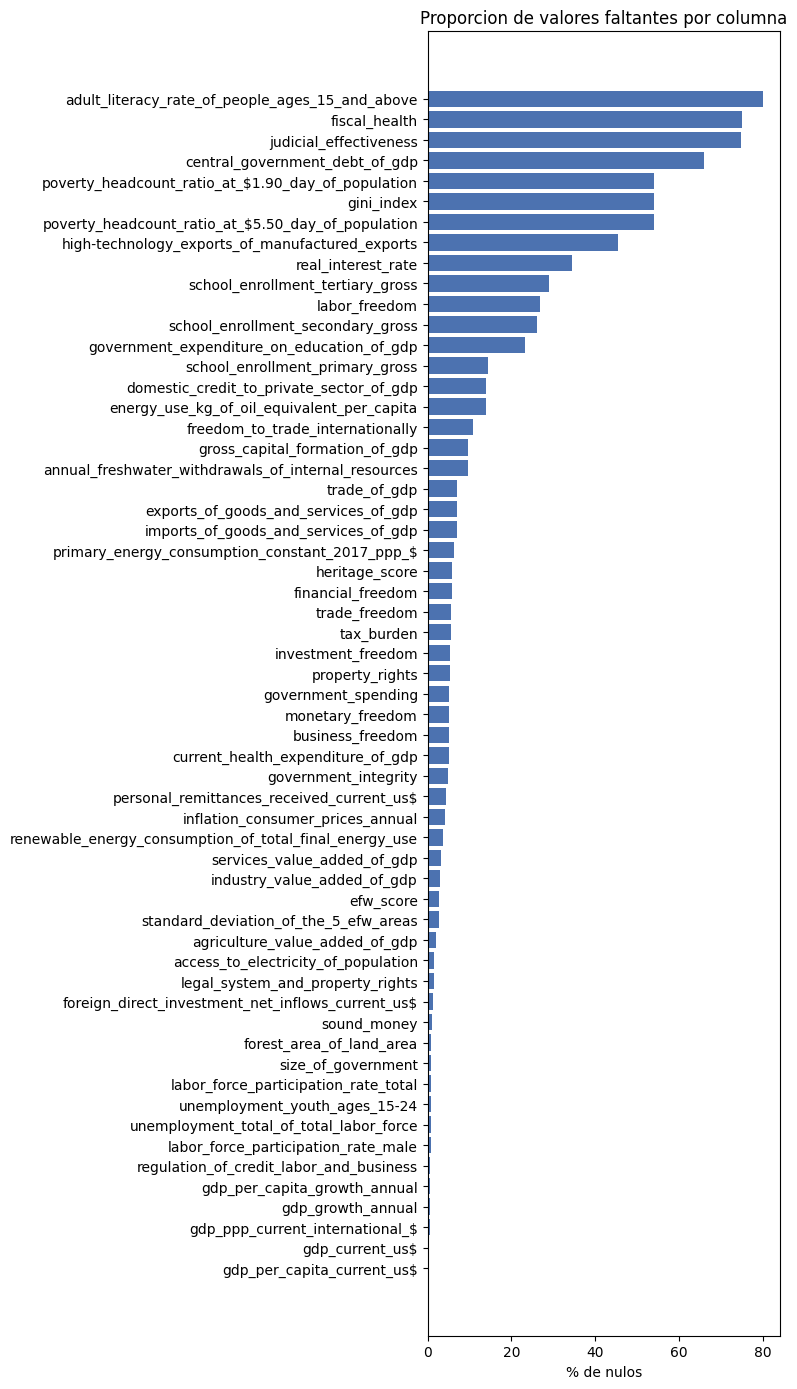

Columnas sin nulos: 6 de 64


In [5]:
resumen_nulos = pd.DataFrame({
    'Tipo de dato': df.dtypes.astype(str),
    'No nulos': df.notna().sum(),
    'Nulos': df.isna().sum(),
    '% nulos': (df.isna().sum() / len(df) * 100).round(2),
}).sort_values('% nulos', ascending=False)

# Se muestra sin estilizar (mismo criterio que TP2): mezcla texto + numeros, y lo
# que importa aca es poder ordenar/leer la tabla completa, no resaltarla con color.
display(resumen_nulos)

# Barra horizontal de % de nulos: mas legible que msno.matrix con 64 etiquetas en el eje.
datos_grafico = resumen_nulos[resumen_nulos['% nulos'] > 0].sort_values('% nulos')
fig, ax = plt.subplots(figsize=(8, 14))
ax.barh(datos_grafico.index, datos_grafico['% nulos'], color='#4C72B0')
ax.set_xlabel('% de nulos')
ax.set_title('Proporcion de valores faltantes por columna')
plt.tight_layout()
plt.show()

print(f"Columnas sin nulos: {(resumen_nulos['% nulos'] == 0).sum()} de {len(resumen_nulos)}")

### Conclusiones — Nulos por columna

- Solo 6 de 64 columnas no tienen ningún nulo. ¿Qué tipo de variables son las que más faltantes tienen (índices compuestos, indicadores sociales, ambos)?
- ¿Alguna de las variables con muchísimos nulos (`adult_literacy_rate` 80%, `fiscal_health`/`judicial_effectiveness` ~75%) es imprescindible para lo que sigue, o se puede directamente descartar?

<!-- Completar -->

### 3. Patrón de nulos (ubicación y correlación de ausencia)

¿El patrón de nulos es aleatorio, o hay columnas que faltan juntas? Se dispara la heurística de `msno.matrix`/`msno.heatmap` obligatorios (nulos > 5% en la enorme mayoría de columnas). Se acota a las columnas con más de 5% de nulos (33 de 64) para que el heatmap sea legible en vez de forzar una matriz 64×64.

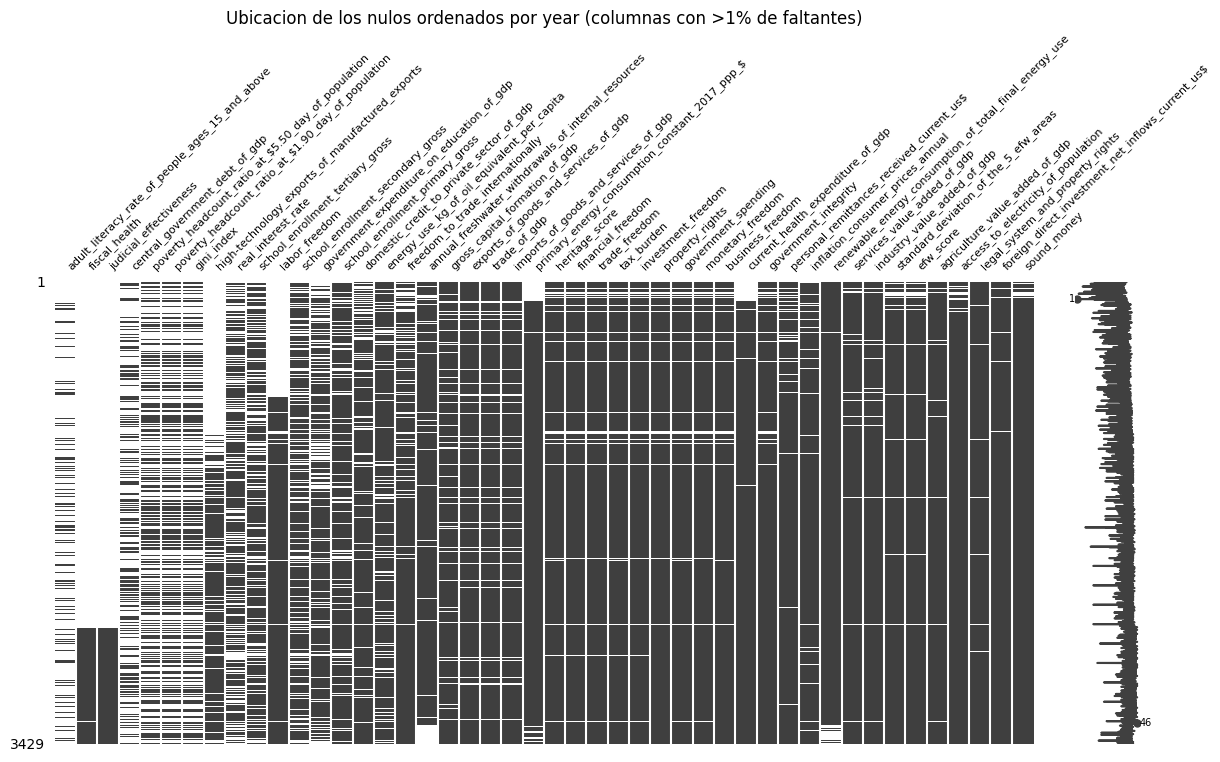

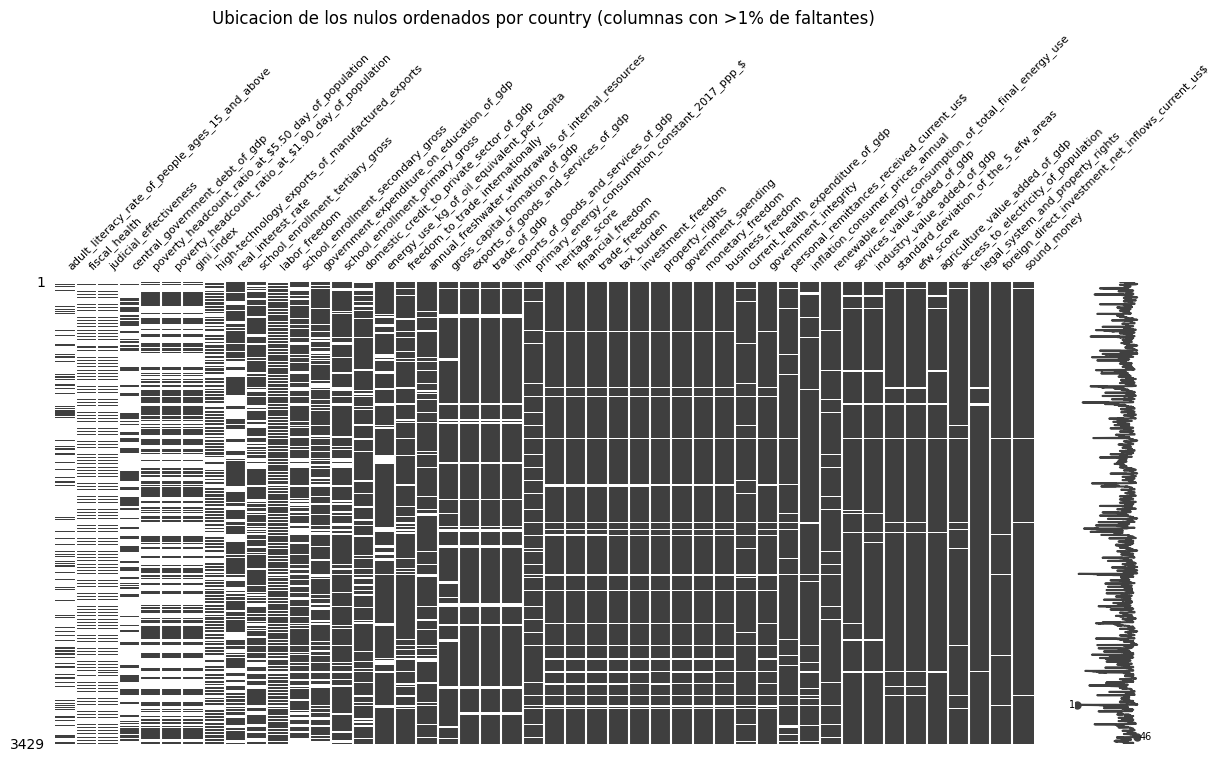

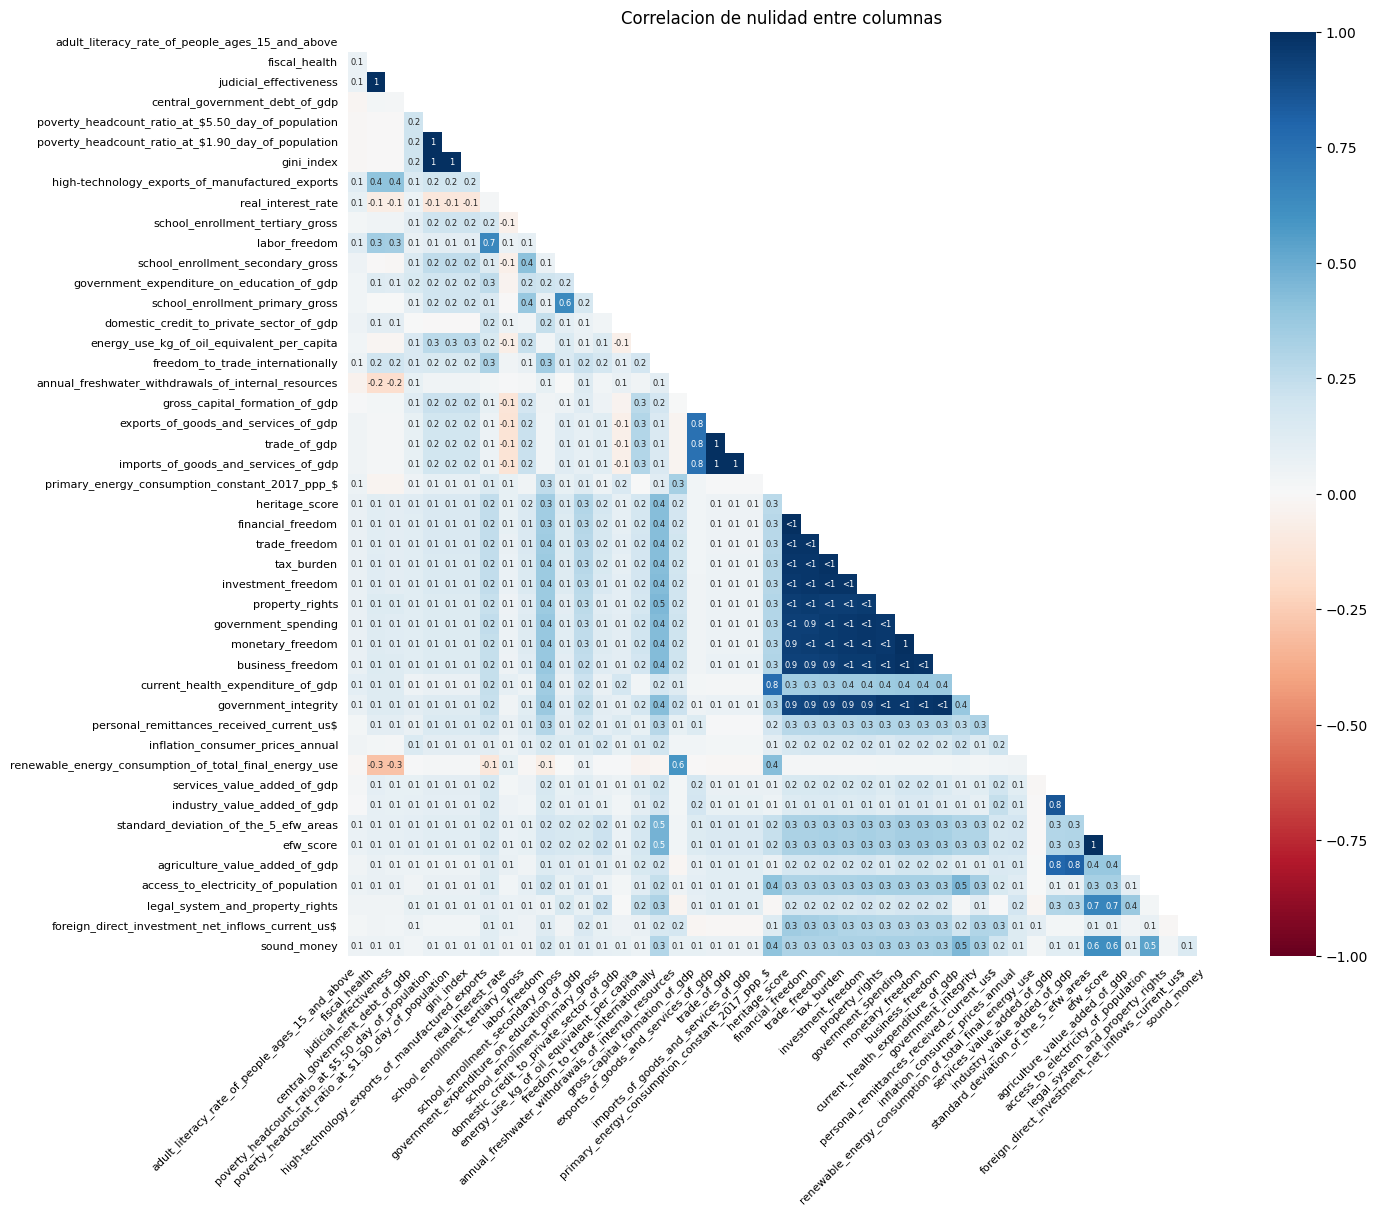

In [19]:
porc = 1
columnas_con_nulos = resumen_nulos[resumen_nulos['% nulos'] > porc].index.tolist()

df_ordenado_por_fecha = df.sort_values(['year','country']).reset_index(drop=True)
df_ordenado_por_pais = df.sort_values(['country', 'year']).reset_index(drop=True)

msno.matrix(df_ordenado_por_fecha[columnas_con_nulos], figsize=(14, 6), fontsize=8)
plt.title(f'Ubicacion de los nulos ordenados por year (columnas con >{porc}% de faltantes)')
plt.show()

msno.matrix(df_ordenado_por_pais[columnas_con_nulos], figsize=(14, 6), fontsize=8)
plt.title(f'Ubicacion de los nulos ordenados por country (columnas con >{porc}% de faltantes)')
plt.show()

msno.heatmap(df[columnas_con_nulos], figsize=(14, 12), fontsize=8)
plt.title('Correlacion de nulidad entre columnas')
plt.show()

### Conclusiones — Patrón de nulos

- `judicial_effectiveness` y `fiscal_health` tienen correlación de nulidad ≈1, igual que los dos `poverty_headcount_ratio` con `gini_index`. ¿Qué sugiere esto sobre el origen de esos faltantes (una misma encuesta/fuente que no cubre ciertos países-año)?
- ¿Este patrón es más compatible con MCAR (aleatorio) o con MAR/MNAR (asociado a qué tan desarrollado está el país o a qué tan buena es su infraestructura estadística)?

<!-- Completar -->

# Dendrograma entre features

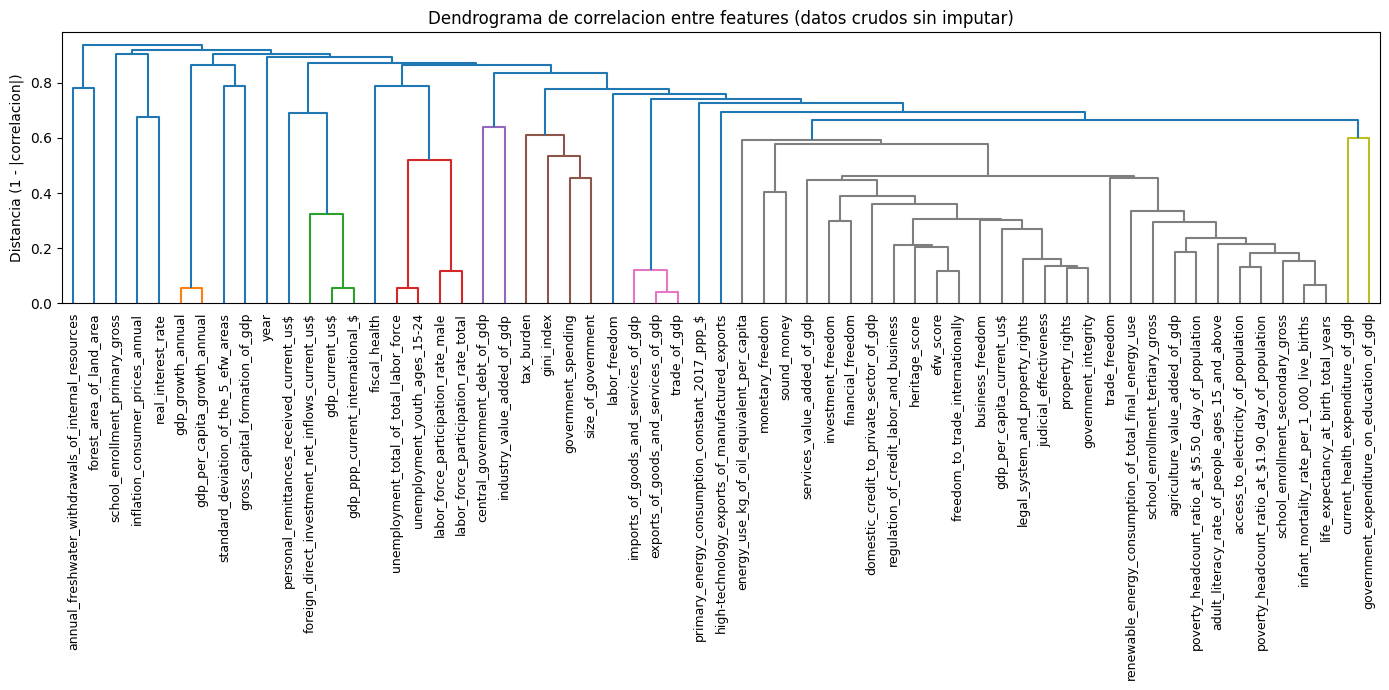

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

variables_numericas = df.select_dtypes(include='number').columns.tolist()

def calcular_matriz_correlacion(df, columnas):
    """Correlacion pairwise-complete: cada par de columnas usa solo las filas
    donde ambas tienen dato, sin necesidad de imputar previamente."""
    return df[columnas].corr()

def graficar_dendrograma_correlacion(matriz_corr, titulo):
    # Convertimos correlacion en distancia: 1 - |corr|. Variables muy
    # correlacionadas (en valor absoluto) quedan cerca; da igual el signo,
    # porque para elegir predictor de imputacion nos interesa la fuerza del
    # vinculo, no la direccion.
    distancia = (1 - matriz_corr.abs()).to_numpy().copy()
    np.fill_diagonal(distancia, 0)
    distancia_condensada = squareform(distancia, checks=False)
    enlaces = linkage(distancia_condensada, method='average')

    fig, ax = plt.subplots(figsize=(14, 7))
    dendrogram(enlaces, labels=matriz_corr.columns.tolist(),
               leaf_rotation=90, leaf_font_size=9, ax=ax)
    ax.set_title(titulo)
    ax.set_ylabel('Distancia (1 - |correlacion|)')
    plt.tight_layout()
    plt.show()

matriz_corr_cruda = calcular_matriz_correlacion(df, variables_numericas)

graficar_dendrograma_correlacion(matriz_corr_cruda,
    'Dendrograma de correlacion entre features (datos crudos sin imputar)')

### 4. Rango y orden de magnitud de cada variable numérica

`describe()` transpuesto y coloreado por columna (cada estadístico se compara contra sí mismo a través de las variables) para que salte a la vista la diferencia de escalas.

In [7]:
describe_numericas = df[columnas_numericas].describe().T
display(estilizar(describe_numericas, cmap='Blues', precision=2))

,count,mean,std,min,25%,50%,75%,max
heritage_score,3231.00,61.45,9.82,15.60,54.80,61.00,68.10,89.70
property_rights,3250.00,50.24,22.96,5.00,30.00,50.00,70.00,100.00
government_integrity,3262.00,43.13,22.29,0.00,27.00,36.00,55.00,100.00
judicial_effectiveness,860.00,48.28,20.61,7.10,32.38,45.70,61.60,98.00
tax_burden,3241.00,74.61,13.53,10.00,66.60,76.60,83.70,100.00
government_spending,3251.00,64.67,22.90,0.00,50.70,69.70,83.10,97.60
fiscal_health,856.00,66.23,29.81,0.00,48.83,77.60,90.60,100.00
business_freedom,3256.00,65.01,15.08,20.00,55.00,66.05,74.50,100.00
labor_freedom,2513.00,61.25,14.88,20.00,50.50,60.90,71.50,100.00
monetary_freedom,3252.00,75.63,11.12,0.00,72.10,77.40,81.70,95.40


### Conclusiones — Rango y magnitud

- ¿Qué grupos de variables comparten escala (por ejemplo, los sub-índices de libertad económica en 0-100) y cuáles están en unidades completamente distintas (USD corrientes, kg de petróleo equivalente per cápita, años de vida)?
- Dada esta disparidad de escalas, ¿qué familias de modelos del resto de la guía (Ejercicio 3 en adelante) van a necesitar estandarización sí o sí?

<!-- Completar -->

### 5. Correlación con el target

Con 60 variables numéricas no tiene sentido graficar la distribución de todas ("principales variables" de la consigna) — se usa la correlación de Pearson con el target como criterio objetivo de selección. De paso, esto anticipa el filtro univariado que el Ejercicio 3 va a aplicar formalmente (no se resuelve acá).

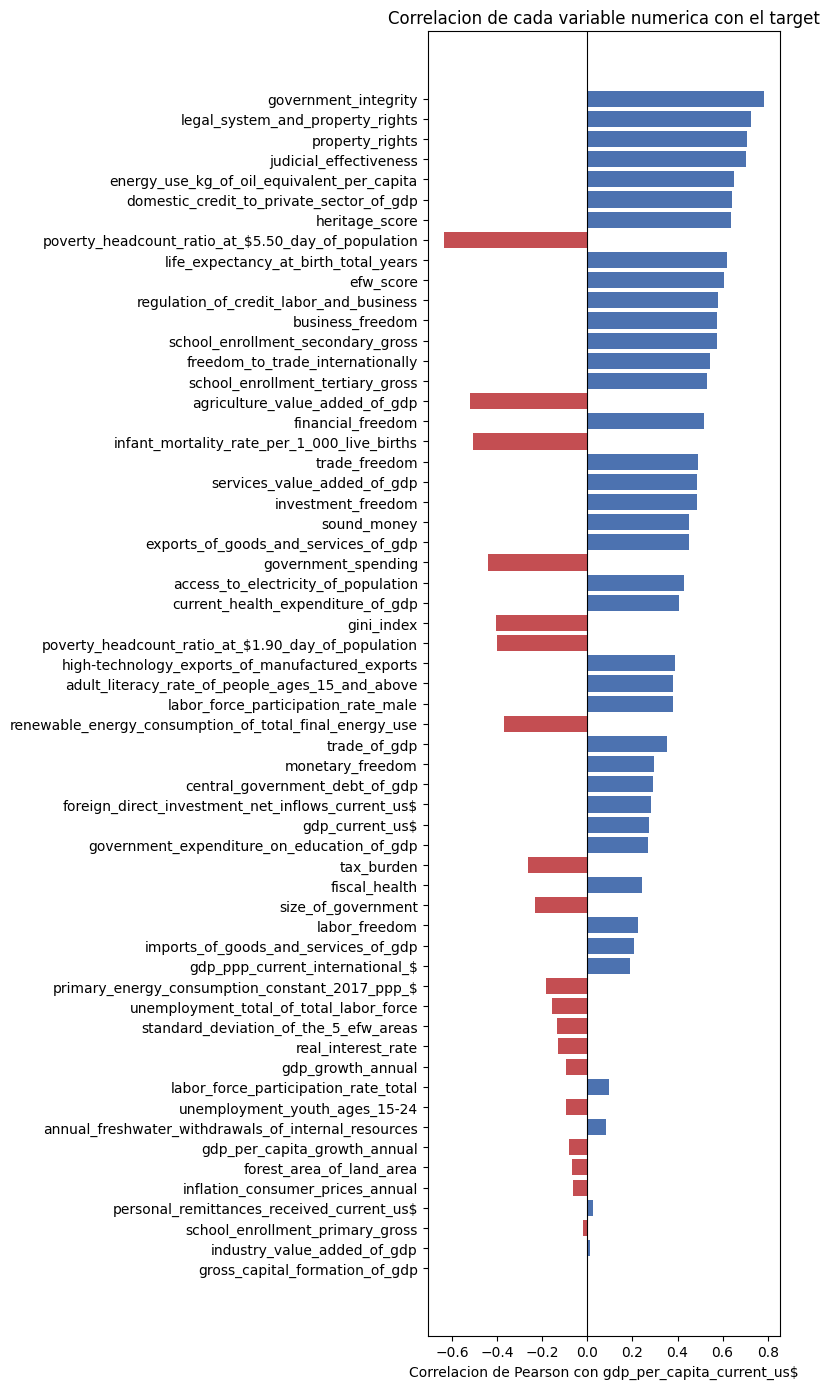

,Correlacion con el target
government_integrity,0.783711
legal_system_and_property_rights,0.725604
property_rights,0.708138
judicial_effectiveness,0.704392
energy_use_kg_of_oil_equivalent_per_capita,0.650296
domestic_credit_to_private_sector_of_gdp,0.641496
heritage_score,0.639413
poverty_headcount_ratio_at_$5.50_day_of_population,-0.637547
life_expectancy_at_birth_total_years,0.620615
efw_score,0.604387


In [8]:
correlacion_target = df[columnas_numericas].corr(numeric_only=True)[TARGET].drop(TARGET)
correlacion_target = correlacion_target.reindex(correlacion_target.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 14))
colores = ['#4C72B0' if v > 0 else '#C44E52' for v in correlacion_target.values]
ax.barh(correlacion_target.index[::-1], correlacion_target.values[::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Correlacion de Pearson con {TARGET}')
ax.set_title('Correlacion de cada variable numerica con el target')
plt.tight_layout()
plt.show()

# Top 10 por |r|: es el subconjunto que se usa en el punto 6 como "variables principales".
variables_principales = correlacion_target.head(10).index.tolist()
display(correlacion_target.head(10).rename('Correlacion con el target').to_frame())

### Conclusiones — Correlación con el target

- Las variables más correlacionadas son mayormente sub-índices de institucionalidad (`government_integrity`, `property_rights`, `judicial_effectiveness`) más que variables "económicas" directas. ¿Te sorprende, o tiene sentido con lo que sabés de desarrollo económico?
- Todas estas correlaciones son con la escala original del target (`gdp_per_capita_current_us$`, con skew alto). ¿Cambiaría el ranking si se calculara sobre el target transformado (log)? Es una pregunta para cuando llegues al punto 3 de este mismo ejercicio.

<!-- Completar -->

### 6. Distribuciones de las variables principales

Histograma+KDE, boxplot y tabla de skewness/curtosis del target y las 10 variables más correlacionadas con él. Q-Q plot automático en las que tengan \|skew\| > 1 (heurística de asimetría relevante).

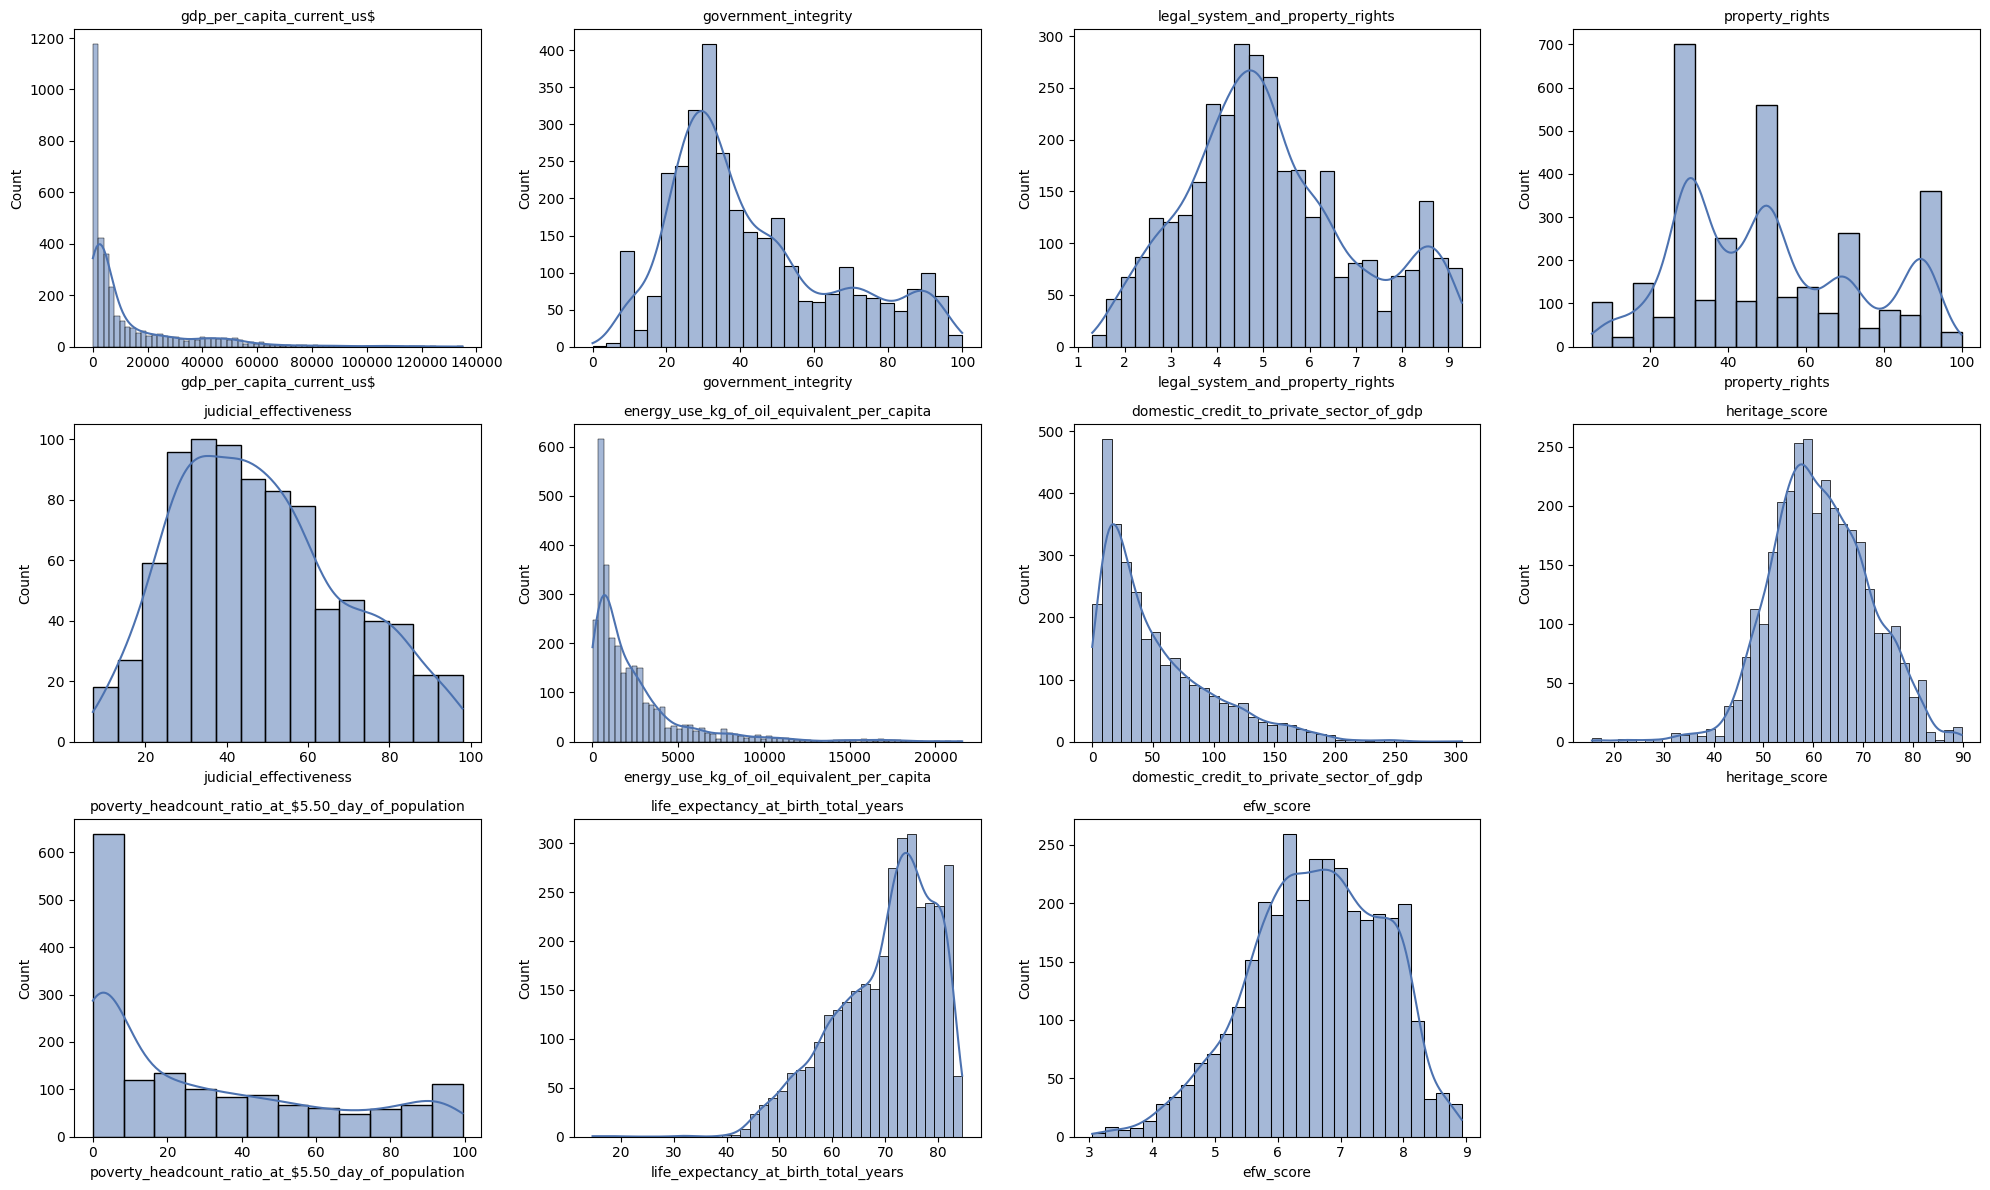

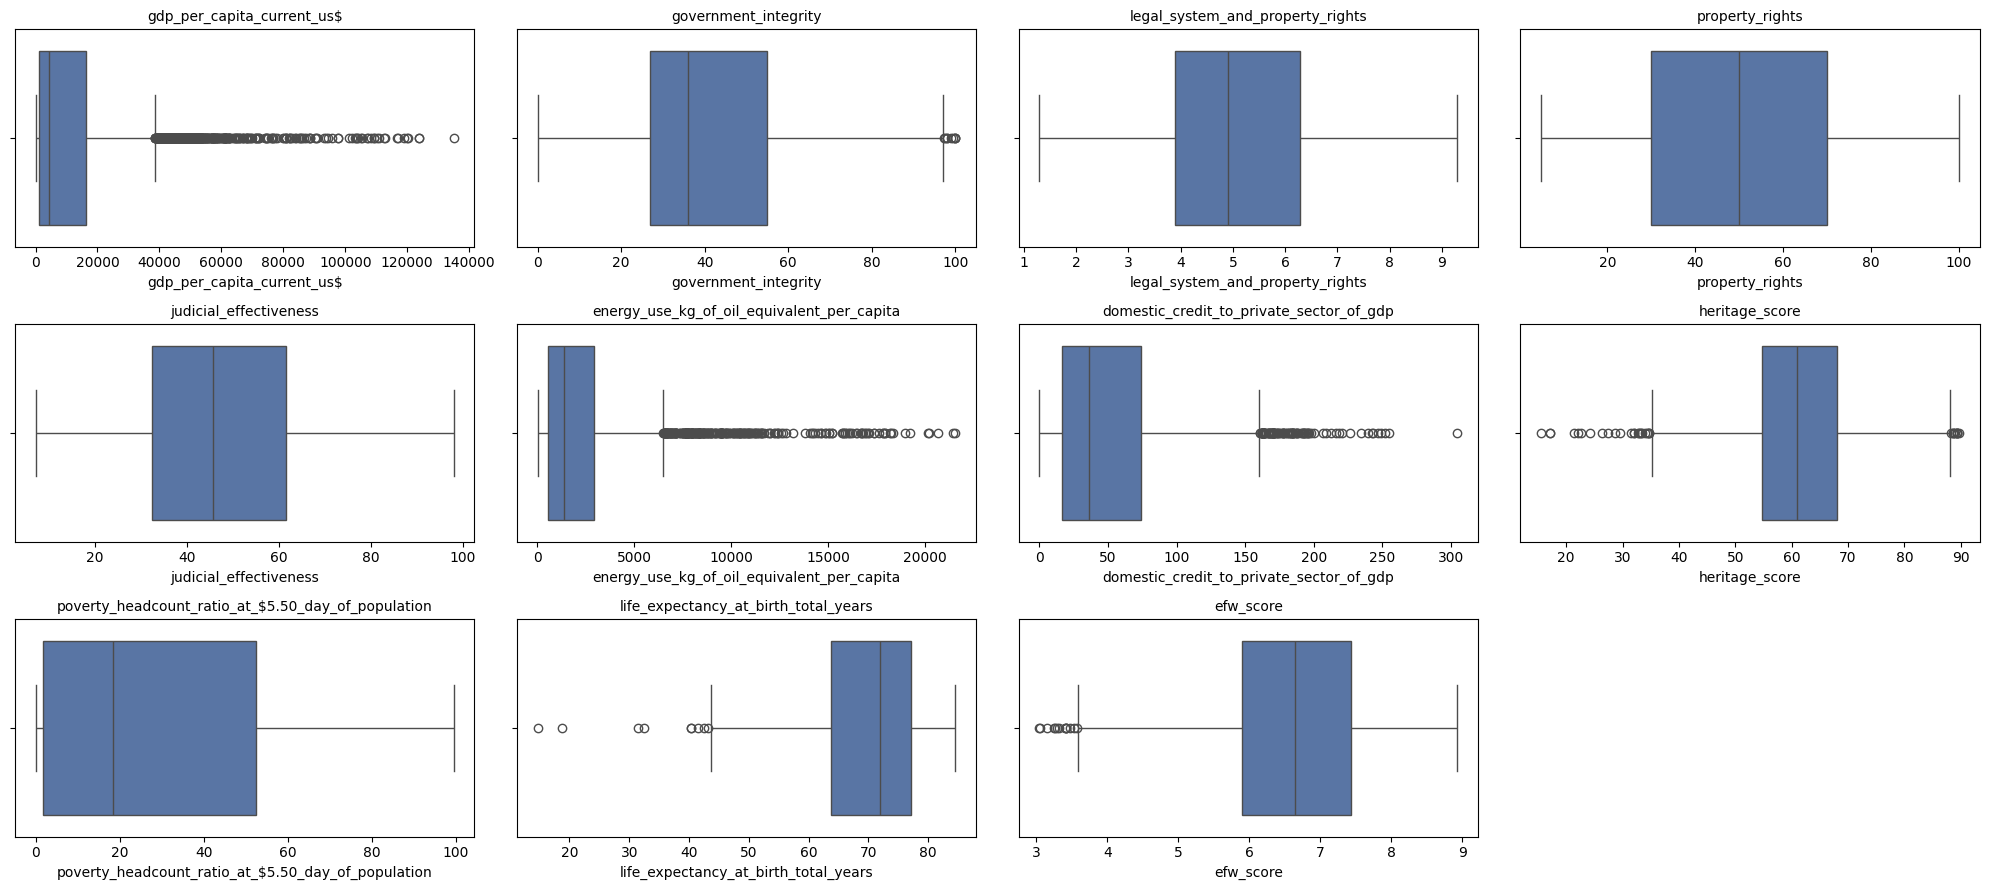

,Skewness,Curtosis,% nulos
Variable,,,
gdp_per_capita_current_us$,2.31,6.10,0.03
government_integrity,0.79,-0.31,4.87
legal_system_and_property_rights,0.42,-0.48,1.40
property_rights,0.39,-0.86,5.22
judicial_effectiveness,0.41,-0.59,74.92
energy_use_kg_of_oil_equivalent_per_capita,2.69,8.98,13.85
domestic_credit_to_private_sector_of_gdp,1.36,1.68,13.85
heritage_score,-0.05,0.46,5.77
poverty_headcount_ratio_at_$5.50_day_of_population,0.81,-0.71,54.10


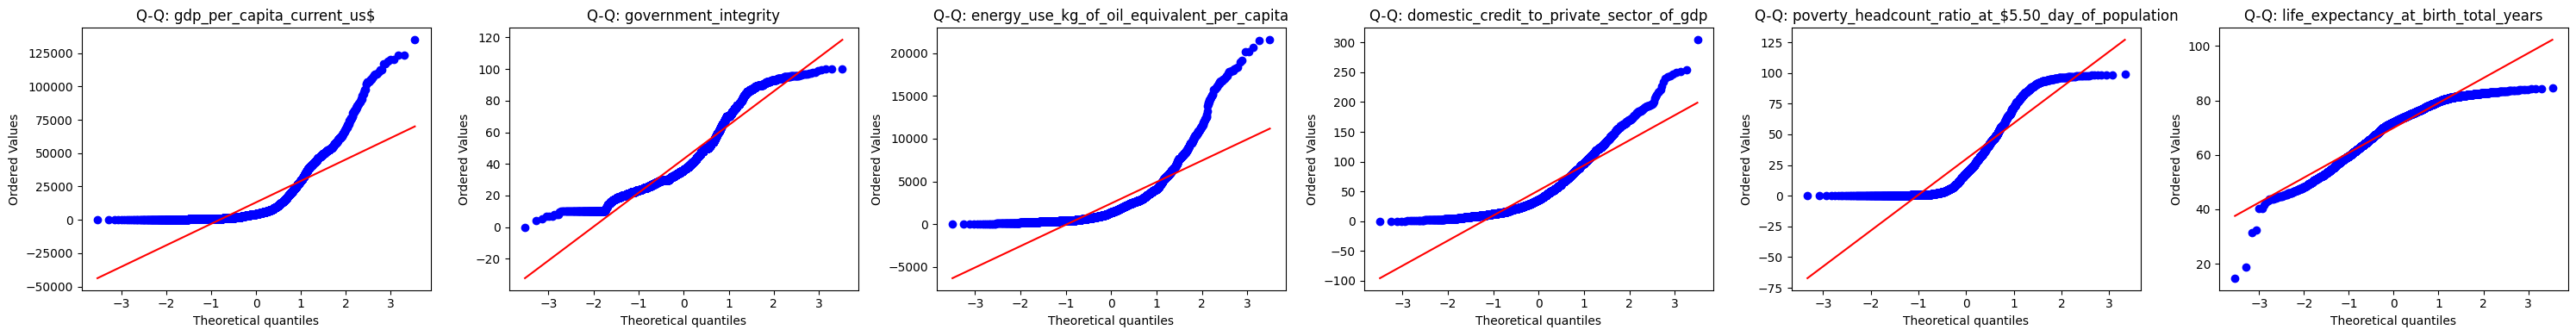

Q-Q automatico por |skew| > 1 en: gdp_per_capita_current_us$, government_integrity, energy_use_kg_of_oil_equivalent_per_capita, domestic_credit_to_private_sector_of_gdp, poverty_headcount_ratio_at_$5.50_day_of_population, life_expectancy_at_birth_total_years


In [9]:
variables_a_graficar = [TARGET] + variables_principales
n_cols = 4
n_filas = int(np.ceil(len(variables_a_graficar) / n_cols))

# Histogramas + KDE
fig, axes = plt.subplots(n_filas, n_cols, figsize=(20, 4 * n_filas))
axes = axes.flatten()
for i, col in enumerate(variables_a_graficar):
  sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#4C72B0')
  axes[i].set_title(col, fontsize=10)
for j in range(len(variables_a_graficar), len(axes)):
  fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Boxplots (misma grilla, para ver outliers y dispersion)
fig, axes = plt.subplots(n_filas, n_cols, figsize=(20, 3 * n_filas))
axes = axes.flatten()
for i, col in enumerate(variables_a_graficar):
  sns.boxplot(x=df[col].dropna(), ax=axes[i], color='#4C72B0')
  axes[i].set_title(col, fontsize=10)
for j in range(len(variables_a_graficar), len(axes)):
  fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Tabla de skewness/curtosis
filas_skew = []
for col in variables_a_graficar:
  serie = df[col].dropna()
  filas_skew.append({
      'Variable': col,
      'Skewness': stats.skew(serie),
      'Curtosis': stats.kurtosis(serie),
      '% nulos': df[col].isna().mean() * 100,
  })
tabla_skew = pd.DataFrame(filas_skew).set_index('Variable')
display(estilizar(tabla_skew, cmap='Oranges', precision=2))

# Q-Q plot automatico: heuristica, |skew| > 1 indica asimetria relevante para decisiones posteriores
vars_asimetricas = tabla_skew[tabla_skew['Skewness'].abs() > 0.5].index.tolist()
if vars_asimetricas:
  fig, axes = plt.subplots(1, len(vars_asimetricas), figsize=(5 * len(vars_asimetricas), 4))
  if len(vars_asimetricas) == 1:
    axes = [axes]
  for ax, col in zip(axes, vars_asimetricas):
    stats.probplot(df[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {col}')
  plt.tight_layout()
  plt.show()
  print(f"Q-Q automatico por |skew| > 1 en: {', '.join(vars_asimetricas)}")

### Conclusiones — Distribuciones

- `gdp_per_capita_current_us$` (el target) tiene skew ≈2.3: muy concentrado en valores bajos con una cola larga de países ricos. ¿Qué transformación (punto 3 de este ejercicio) tiene más sentido para esto?
- `energy_use_kg_of_oil_equivalent_per_capita` y `domestic_credit_to_private_sector_of_gdp` también salen asimétricas — ¿por qué transformación pasarías cada una?
- Los sub-índices de institucionalidad (`government_integrity`, `property_rights`, etc.) tienen formas bastante distintas entre sí a pesar de compartir escala 0-100 (algunos multimodales). ¿Qué podría explicar esa multimodalidad?

<!-- Completar -->

### 7. Sub-índices de libertad económica (misma escala 0-100)

Boxplot comparativo — tiene sentido ponerlos en un mismo panel porque comparten unidad, a diferencia de mezclarlos con variables en USD o años de vida.

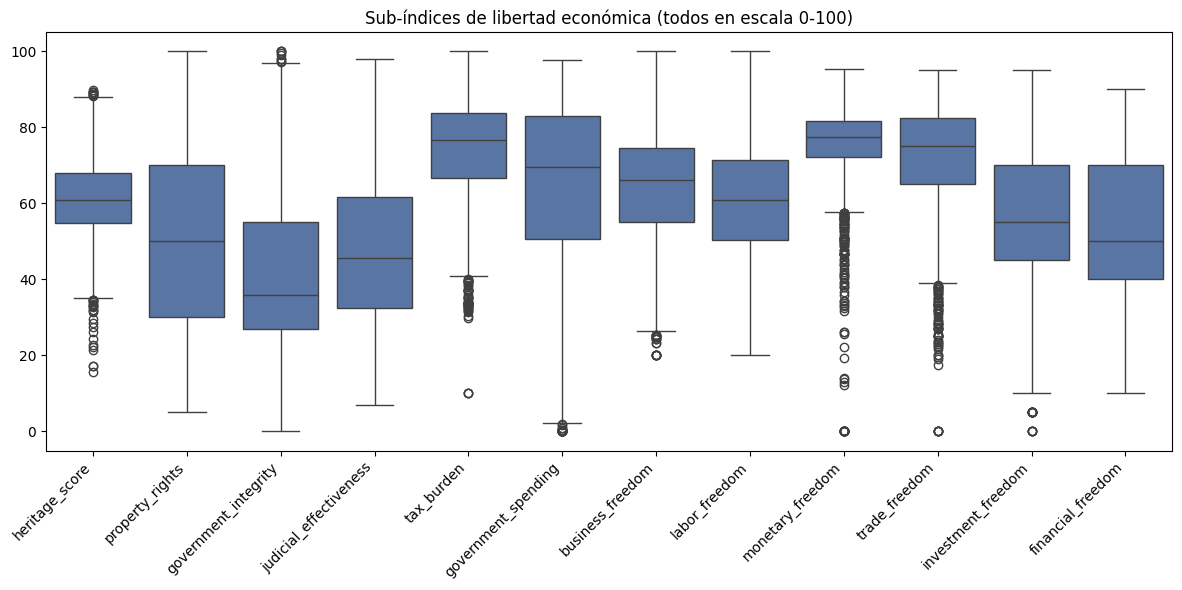

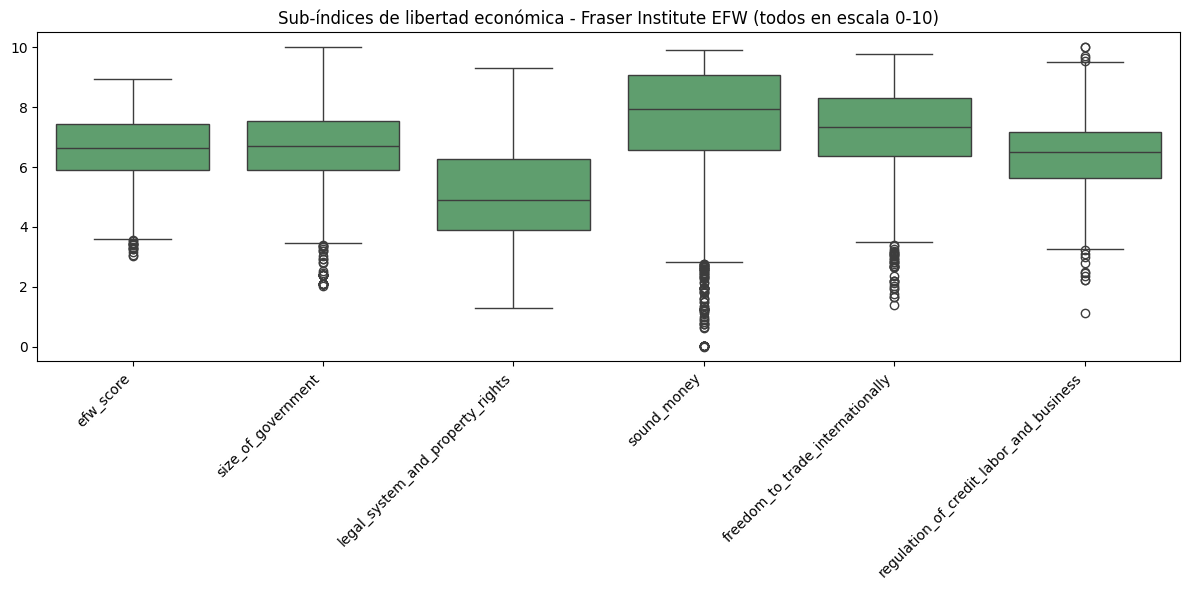

In [12]:
indices_libertad_100 = ['heritage_score', 'property_rights', 'government_integrity',
                         'judicial_effectiveness', 'tax_burden', 'government_spending',
                         'business_freedom', 'labor_freedom', 'monetary_freedom',
                         'trade_freedom', 'investment_freedom', 'financial_freedom']
indices_libertad_100 = [c for c in indices_libertad_100 if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[indices_libertad_100], ax=ax, color='#4C72B0')
ax.set_xticks(range(len(indices_libertad_100)))
ax.set_xticklabels(indices_libertad_100, rotation=45, ha='right')
ax.set_title('Sub-índices de libertad económica (todos en escala 0-100)')
plt.tight_layout()
plt.show()

indices_libertad_efw = ['efw_score', 'size_of_government', 'legal_system_and_property_rights',
                         'sound_money', 'freedom_to_trade_internationally',
                         'regulation_of_credit_labor_and_business']
indices_libertad_efw = [c for c in indices_libertad_efw if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[indices_libertad_efw], ax=ax, color='#55A868')
ax.set_xticks(range(len(indices_libertad_efw)))
ax.set_xticklabels(indices_libertad_efw, rotation=45, ha='right')
ax.set_title('Sub-índices de libertad económica - Fraser Institute EFW (todos en escala 0-10)')
plt.tight_layout()
plt.show()

### Conclusiones — Sub-índices de libertad económica

- ¿Cuáles de estos sub-índices tienen mayor dispersión entre países, y cuáles están más concentrados (poca variabilidad, quizás poco útiles para diferenciar países)?
- ¿Hay algún sub-índice con outliers claramente marcados en el boxplot? ¿Coincide con algún país que ya viste en las variables anteriores?

<!-- Completar -->

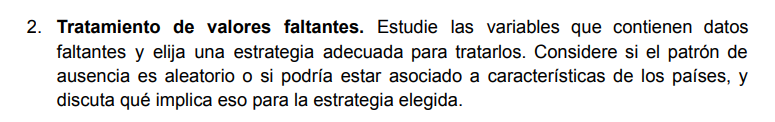

### Conclusiones del EDA — Diagnóstico de valores faltantes

- **MAR temporal confirmado:** `fiscal_health` y `judicial_effectiveness` faltan
  siempre antes de un mismo año de corte (correlación de nulidad = 1 entre
  ambas). La causa es externa y verificable: Heritage Foundation incorporó estos
  dos componentes a su metodología recién a partir de 2017, por lo que las
  observaciones anteriores nunca tuvieron ese dato disponible — no es un
  problema de reporte del país, sino de cobertura temporal de la fuente.

- **MAR temporal sospechado (pendiente de confirmar):** `current_health_expenditure_of_gdp`,
  `primary_energy_consumption_constant_2017_ppp_$`, `labor_freedom` y
  `high-technology_exports_of_manufactured_exports` muestran el mismo patrón
  "peine" (faltante al inicio de la serie de cada país) en la vista ordenada por
  `['country', 'year']`, pero con un año de corte propio, no necesariamente 2017.
  Se decidió verificar el primer año no-nulo por país antes de asumir MAR.

- **Bloques co-publicados:** las columnas de Heritage Foundation (`heritage_score`
  y sus 12 componentes), de Fraser Institute/EFW (`efw_score` y sus áreas) y el
  trío de comercio exterior (`exports_of_goods_and_services_of_gdp`,
  `imports_of_goods_and_services_of_gdp`, `trade_of_gdp`) faltan siempre juntas
  dentro de cada bloque (correlación de nulidad cercana a 1). Esto se explica
  porque cada bloque proviene de un único reporte/cálculo por país-año: si falta
  uno de sus componentes, faltan todos. Queda pendiente verificar si, dentro de
  cada bloque, el faltante es por corte temporal (MAR) o por países enteros sin
  cobertura de esa fuente.

- **Sospecha de MNAR — `poverty_headcount_ratio_at_$1.90_day`,
  `poverty_headcount_ratio_at_$5.50_day` y `gini_index`:** a diferencia de los
  casos anteriores, estas tres faltan en bloques de **países completos** (no en
  un rango de años), lo cual es compatible con que dependan de encuestas de
  hogares que muchos países no levantan con regularidad. Se decidió comparar su
  faltante contra variables de calidad institucional (`heritage_score`,
  `property_rights`, `government_integrity`, `judicial_effectiveness`,
  `legal_system_and_property_rights`) en lugar de contra el propio target,
  porque esas variables institucionales las calcula un organismo externo
  (Heritage Foundation / Fraser Institute) y no dependen de que el país publique
  su propia estadística — evita comparar el faltante contra una fuente que podría
  compartir el mismo mecanismo de generación del dato.

- **Sin patrón claro todavía:** `domestic_credit_to_private_sector_of_gdp`,
  `energy_use_kg_of_oil_equivalent_per_capita`, `freedom_to_trade_internationally`,
  `annual_freshwater_withdrawals_of_internal_resources`, `gross_capital_formation_of_gdp`,
  `real_interest_rate` y el sub-bloque de matrícula escolar
  (`school_enrollment_primary/secondary/tertiary_gross` +
  `government_expenditure_on_education_of_gdp`) muestran correlaciones de
  nulidad bajas con el resto. Se decidió no agruparlas ni clasificarlas todavía
  — revisión individual pendiente antes del inciso de imputación.

- **Próximo paso decidido:** correr tres verificaciones antes de cerrar la
  clasificación — (1) primer año no-nulo por país para el grupo MAR sospechado,
  (2) matriz de nulidad ordenada por país dentro de cada bloque co-publicado,
  (3) comparación estadística (Mann-Whitney) de calidad institucional entre
  países con y sin `poverty_headcount_ratio`/`gini_index` disponible.


primer_anio_con_dato,cantidad_paises
2000,138
2003,2
2010,1
2011,1
2013,1
2014,1


primer_anio_con_dato,cantidad_paises
2000,140
2002,1
2005,1
2011,1
2014,1


primer_anio_con_dato,cantidad_paises
2005,130
2006,2
2009,8
2013,2
2014,1
2017,1


primer_anio_con_dato,cantidad_paises
2007,67
2008,27
2009,15
2010,7
2011,2
2012,3
2013,6
2014,3
2015,4
2016,2


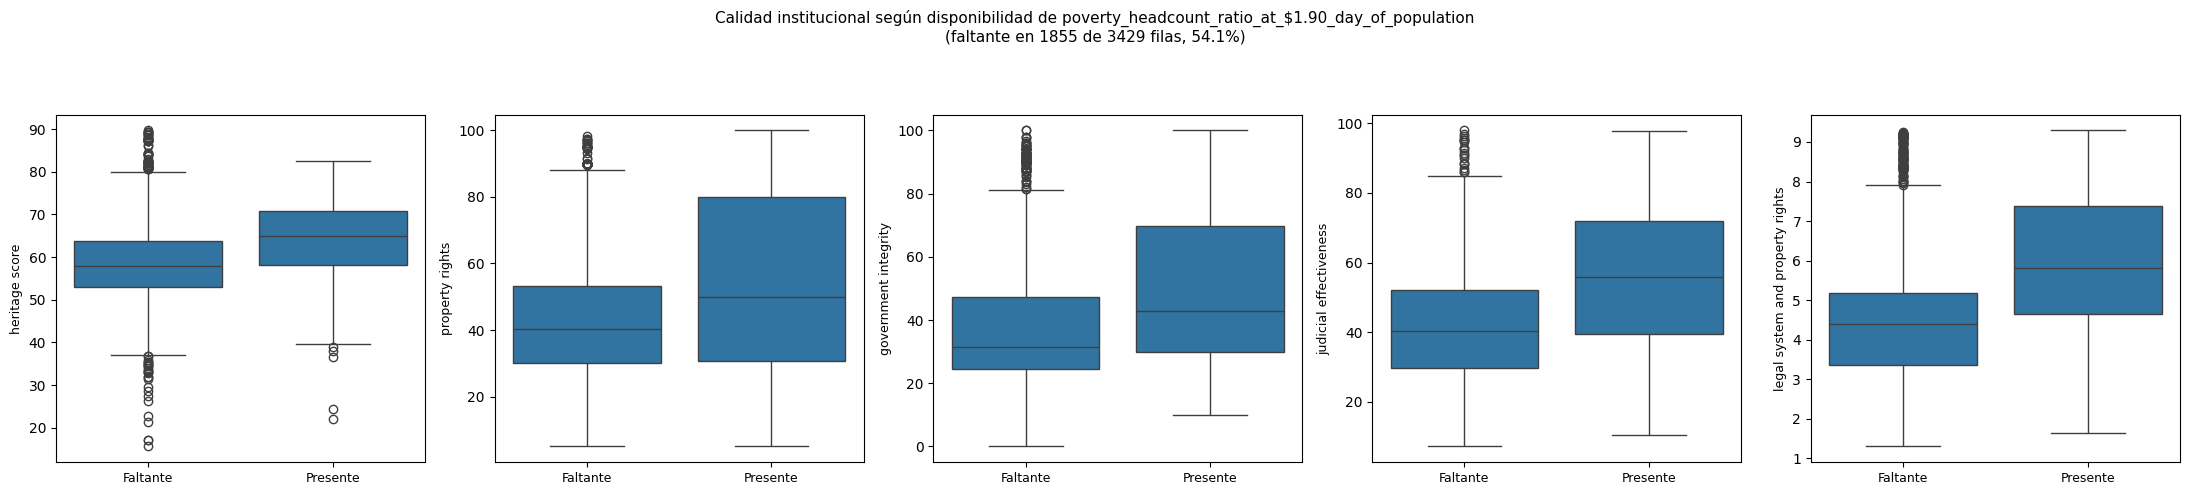

variable_institucional,n_grupo_faltante,n_grupo_presente,mediana_grupo_faltante,mediana_grupo_presente,diferencia_mediana,p_valor
heritage_score,1687,1544,57.800,64.900,-7.100,0.000
property_rights,1706,1544,40.300,50.050,-9.750,0.000
government_integrity,1717,1545,31.600,43.000,-11.400,0.000
judicial_effectiveness,468,392,40.250,55.750,-15.500,0.000
legal_system_and_property_rights,1813,1568,4.386,5.818,-1.432,0.000


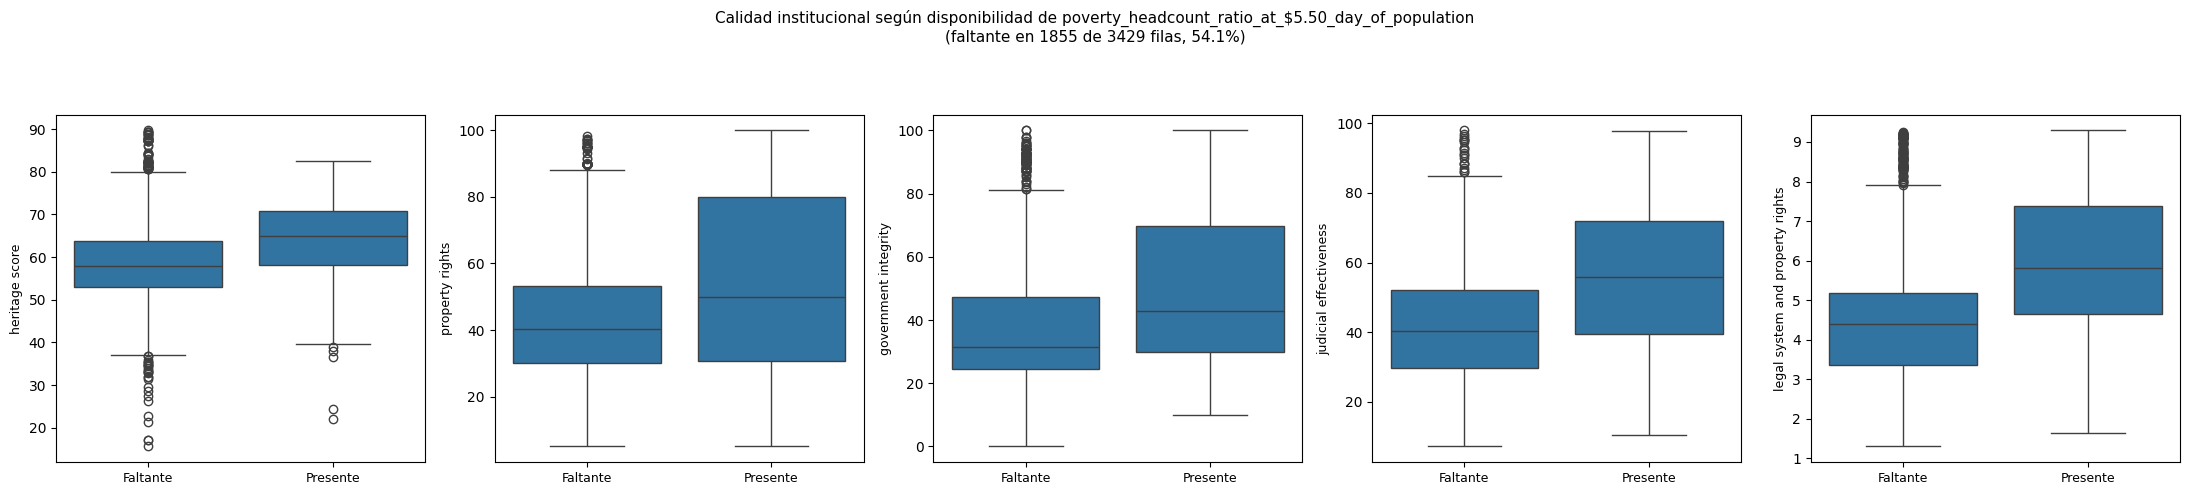

variable_institucional,n_grupo_faltante,n_grupo_presente,mediana_grupo_faltante,mediana_grupo_presente,diferencia_mediana,p_valor
heritage_score,1687,1544,57.800,64.900,-7.100,0.000
property_rights,1706,1544,40.300,50.050,-9.750,0.000
government_integrity,1717,1545,31.600,43.000,-11.400,0.000
judicial_effectiveness,468,392,40.250,55.750,-15.500,0.000
legal_system_and_property_rights,1813,1568,4.386,5.818,-1.432,0.000


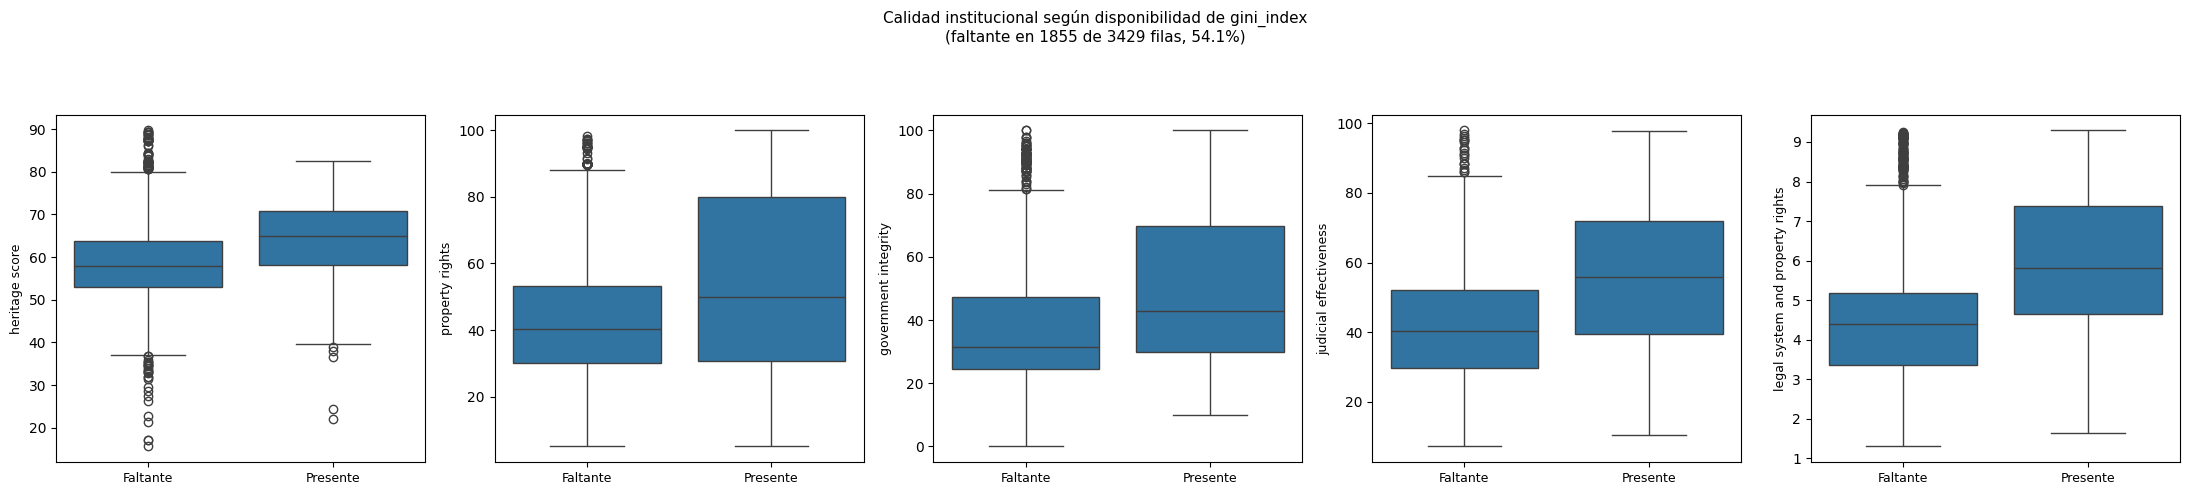

variable_institucional,n_grupo_faltante,n_grupo_presente,mediana_grupo_faltante,mediana_grupo_presente,diferencia_mediana,p_valor
heritage_score,1687,1544,57.800,64.900,-7.100,0.000
property_rights,1706,1544,40.300,50.050,-9.750,0.000
government_integrity,1717,1545,31.600,43.000,-11.400,0.000
judicial_effectiveness,468,392,40.250,55.750,-15.500,0.000
legal_system_and_property_rights,1813,1568,4.386,5.818,-1.432,0.000


In [23]:
from IPython.display import display
from scipy.stats import mannwhitneyu

def estilizar_tabla(df, columnas_gradiente=None, columnas_gradiente_invertido=None,
                     columnas_gradiente_centrada=None, titulo=None):
    estilo = df.style.hide(axis='index')
    if titulo:
        estilo = estilo.set_caption(titulo)
    if columnas_gradiente:
        # Valor alto = color más intenso (ej. cantidad de países).
        estilo = estilo.background_gradient(subset=columnas_gradiente, cmap='Blues')
    if columnas_gradiente_invertido:
        # Valor BAJO = color más intenso (ej. p-valor: cuanto más chico, más
        # significativo, así que se invierte la escala).
        estilo = estilo.background_gradient(subset=columnas_gradiente_invertido, cmap='Blues_r')
    if columnas_gradiente_centrada:
        # Paleta divergente centrada en 0 para columnas con signo (ej. diferencia
        # de medianas: por encima o por debajo del grupo de referencia).
        limite = df[columnas_gradiente_centrada].abs().max().max()
        estilo = estilo.background_gradient(
            subset=columnas_gradiente_centrada, cmap='coolwarm', vmin=-limite, vmax=limite
        )
    display(estilo.format(precision=3, na_rep='—'))


# -----------------------------------------------------------------------------
# Parte A — tabla de color en vez de value_counts() impreso
# -----------------------------------------------------------------------------
for columna in columnas_mar_sospechado:
    primer_anio = primer_anio_no_nulo_por_pais(df, columna)
    conteo = primer_anio.value_counts().sort_index()
    tabla_primer_anio = pd.DataFrame({
        'primer_anio_con_dato': conteo.index,
        'cantidad_paises': conteo.values,
    })
    estilizar_tabla(
        tabla_primer_anio,
        columnas_gradiente=['cantidad_paises'],
        titulo=f'{columna} — año del primer dato no nulo, por país',
    )


# -----------------------------------------------------------------------------
# Parte C — tabla resumen con color + boxplots con etiquetas cortas
# -----------------------------------------------------------------------------
def comparar_institucionalidad_por_faltante(df, columna_objetivo, columnas_institucionales):
    indicador_faltante = df[columna_objetivo].isna()
    n_total = len(df)
    n_faltante = int(indicador_faltante.sum())

    filas_resumen = []
    figura, ejes = plt.subplots(1, len(columnas_institucionales), figsize=(22, 5))

    for eje, columna_institucional in zip(ejes, columnas_institucionales):
        disponible = df[columna_institucional].notna()
        grupo_faltante = df.loc[disponible & indicador_faltante, columna_institucional]
        grupo_presente = df.loc[disponible & ~indicador_faltante, columna_institucional]

        fila = {
            'variable_institucional': columna_institucional,
            'n_grupo_faltante': len(grupo_faltante),
            'n_grupo_presente': len(grupo_presente),
            'mediana_grupo_faltante': np.nan,
            'mediana_grupo_presente': np.nan,
            'diferencia_mediana': np.nan,
            'p_valor': np.nan,
        }

        # Solapamiento insuficiente: no se calcula el test, pero igual se
        # deja la fila (en blanco) para que quede registrado en la tabla.
        if len(grupo_faltante) < 5 or len(grupo_presente) < 5:
            filas_resumen.append(fila)
            eje.set_visible(False)
            continue

        _, p_valor = mannwhitneyu(grupo_faltante, grupo_presente)
        fila['mediana_grupo_faltante'] = grupo_faltante.median()
        fila['mediana_grupo_presente'] = grupo_presente.median()
        fila['diferencia_mediana'] = fila['mediana_grupo_faltante'] - fila['mediana_grupo_presente']
        fila['p_valor'] = p_valor
        filas_resumen.append(fila)

        datos_grafico = pd.DataFrame({
            columna_institucional: df.loc[disponible, columna_institucional],
            'estado': np.where(indicador_faltante[disponible], 'Faltante', 'Presente'),
        })
        sns.boxplot(data=datos_grafico, x='estado', y=columna_institucional, ax=eje)

        # Etiquetas cortas (antes: nombre completo de la columna + salto de
        # línea en cada tick del eje X, lo que las hacía chocar entre subplots).
        eje.set_ylabel(columna_institucional.replace('_', ' '), fontsize=9)
        eje.set_xlabel('')
        eje.tick_params(axis='x', labelsize=9)
        eje.set_title('')

    plt.suptitle(
        f'Calidad institucional según disponibilidad de {columna_objetivo}\n'
        f'(faltante en {n_faltante} de {n_total} filas, {n_faltante / n_total:.1%})',
        fontsize=11,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

    tabla_resumen = pd.DataFrame(filas_resumen)
    estilizar_tabla(
        tabla_resumen,
        columnas_gradiente_invertido=['p_valor'],
        columnas_gradiente_centrada=['diferencia_mediana'],
        titulo=f'Comparación de calidad institucional — {columna_objetivo}',
    )


for columna_objetivo in columnas_pobreza:
    comparar_institucionalidad_por_faltante(df, columna_objetivo, columnas_institucionales)


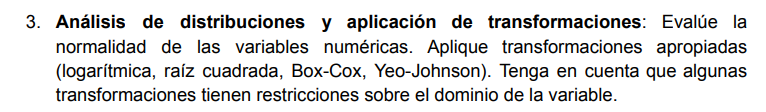

**OBSERVACIÓN**: Las transformaciones aplicadas en este ejercicio no deben entenderse
como una modificación definitiva del dataset. A lo largo de los ejercicios siguientes se
trabajará alternadamente con las variables en su escala original y con las variables
transformadas, según lo requiera cada técnica.

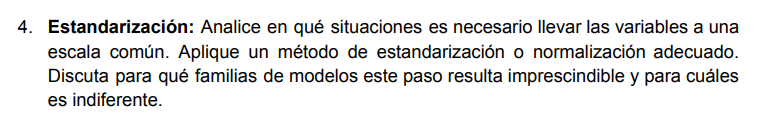